🏦 CITADEL - BUILD THE ALGORITHMIC BLACK BOX
🎯 WEEK 2: MARKET DYNAMICS & AGENT ECOLOGY

VALIDATION TESTS

1. Market Order Test (from PDF):
   Number of trades: 3
   Trade prices: [101, 102, 103]
   Total quantity traded: 60
   Ask book empty: True
   ✅ TEST PASSED

2. No Negative Prices Test:
   Negative prices found: False
   Negative quantities found: False
   ✅ TEST PASSED

3. Spread Non-negative Test:
   Initial spread: 2
   ✅ TEST PASSED

4. Bid < Ask Test:
   Best bid: 99
   Best ask: 101
   ✅ TEST PASSED

RUNNING MARKET SIMULATION SCENARIOS
🚀 CITADEL WEEK 2 - MARKET SIMULATION

▶ Running A: Noise Only...
Running simulation for 120 seconds...
  Generated 716 snapshots, 93 trades

ANALYZING A: Noise Only
Average Spread: 2.0742
Annualized Volatility: 12.29%
Price Range: 100.00 - 101.93
Number of Trades: 93

▶ Running B: Noise + Market Makers...
Running simulation for 120 seconds...
  Generated 747 snapshots, 219 trades

ANALYZING B: Noise + Market Makers
Average Spread: 0.2882
Annua

/tmp/ipython-input-129396211.py:461: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mid_price'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-129396211.py:461: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['mid_price'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-129396211.py:461: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The 

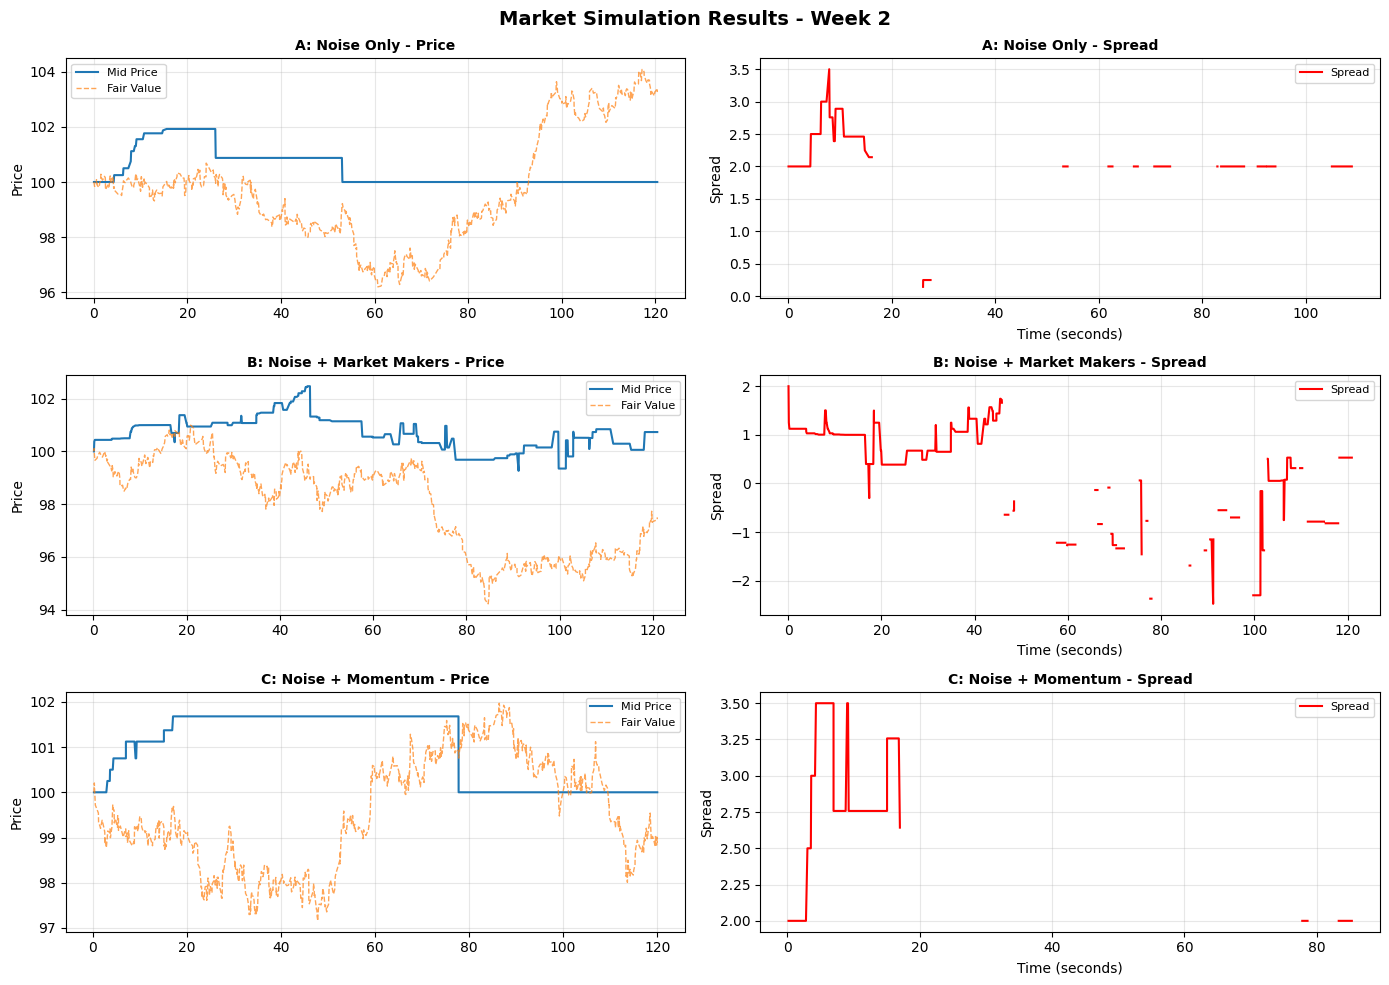


COMPARATIVE METRICS
                Scenario  Avg Spread  Volatility  Trades  Final Price
           A: Noise Only    2.074160    0.122879      93   100.000000
B: Noise + Market Makers    0.288177    0.300403     219   100.734253
     C: Noise + Momentum    2.738920    0.151638      61   100.000000

INTERPRETATION

    1. SCENARIO A (Noise Only):
       - High spread due to no dedicated liquidity providers
       - Price follows random walk around fair value
       - Low trading volume, unstable liquidity
    
    2. SCENARIO B (Noise + Market Makers):
       - Lower spread due to market maker competition
       - More stable prices around fair value
       - Higher trading volume, better liquidity
    
    3. SCENARIO C (Noise + Momentum):
       - Higher volatility due to trend-following behavior
       - Momentum traders amplify price movements
       - Potential for flash-crash-like events when trends reverse
    

✅ Results saved to:
   - market_simulation_results.pdf (plots)
   

In [2]:
# Step 1: Complete Implementation with Proper Integration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import heapq
from collections import deque, defaultdict
import uuid
from abc import ABC, abstractmethod
import random
import time
from datetime import datetime, timedelta

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# ================== 1. ORDER & ORDERBOOK ==================
class Order:
    def __init__(self, order_id, timestamp, order_type, side, price, quantity, agent_id=None):
        self.order_id = order_id
        self.timestamp = timestamp
        self.order_type = order_type  # 'LIMIT' or 'MARKET'
        self.side = side  # 'BUY' or 'SELL'
        self.price = price
        self.quantity = quantity
        self.agent_id = agent_id
        self.status = 'OPEN'
        self.remaining = quantity

    def __repr__(self):
        return f"Order({self.side} {self.quantity}@{self.price})"

class OrderBook:
    def __init__(self):
        self.bids = []  # max-heap (store negative prices)
        self.asks = []  # min-heap
        self.bid_levels = defaultdict(deque)
        self.ask_levels = defaultdict(deque)
        self.orders = {}

    def add_order(self, order):
        self.orders[order.order_id] = order
        if order.side == 'BUY' and order.order_type == 'LIMIT':
            if order.price not in self.bid_levels:
                heapq.heappush(self.bids, -order.price)
            self.bid_levels[order.price].append(order)
        elif order.side == 'SELL' and order.order_type == 'LIMIT':
            if order.price not in self.ask_levels:
                heapq.heappush(self.asks, order.price)
            self.ask_levels[order.price].append(order)

    def get_best_bid(self):
        if not self.bids:
            return None
        while self.bids:
            price = -self.bids[0]
            if price in self.bid_levels and self.bid_levels[price]:
                return price
            heapq.heappop(self.bids)
        return None

    def get_best_ask(self):
        if not self.asks:
            return None
        while self.asks:
            price = self.asks[0]
            if price in self.ask_levels and self.ask_levels[price]:
                return price
            heapq.heappop(self.asks)
        return None

    def get_spread(self):
        bid = self.get_best_bid()
        ask = self.get_best_ask()
        if bid and ask:
            return ask - bid
        return None

    def get_mid_price(self):
        bid = self.get_best_bid()
        ask = self.get_best_ask()
        if bid and ask:
            return (bid + ask) / 2
        return None

# ================== 2. MATCHING ENGINE ==================
class MatchingEngine:
    def __init__(self):
        self.order_book = OrderBook()
        self.trade_log = []

    def submit_order(self, order):
        if order.order_type == 'MARKET':
            self._match_market_order(order)
        else:
            self.order_book.add_order(order)
            self._match_limit_order(order)

    def _match_market_order(self, order):
        self._match(order)

    def _match_limit_order(self, order):
        self._match(order)

    def _match(self, incoming_order):
        remaining = incoming_order.remaining

        while remaining > 0:
            if incoming_order.side == 'BUY':
                best_price = self.order_book.get_best_ask()
                if best_price is None:
                    break
                level_queue = self.order_book.ask_levels[best_price]
                if not level_queue:
                    heapq.heappop(self.order_book.asks)
                    continue
                if incoming_order.order_type == 'LIMIT' and incoming_order.price < best_price:
                    break
            else:  # SELL
                best_price = self.order_book.get_best_bid()
                if best_price is None:
                    break
                level_queue = self.order_book.bid_levels[best_price]
                if not level_queue:
                    heapq.heappop(self.order_book.bids)
                    continue
                if incoming_order.order_type == 'LIMIT' and incoming_order.price > best_price:
                    break

            resting_order = level_queue[0]
            trade_qty = min(remaining, resting_order.remaining)

            # Execute trade
            trade = {
                'timestamp': incoming_order.timestamp,
                'price': best_price,
                'quantity': trade_qty,
                'buyer': incoming_order.agent_id if incoming_order.side == 'BUY' else resting_order.agent_id,
                'seller': resting_order.agent_id if incoming_order.side == 'BUY' else incoming_order.agent_id,
                'aggressor': incoming_order.side
            }
            self.trade_log.append(trade)

            # Update quantities
            remaining -= trade_qty
            incoming_order.remaining = remaining
            resting_order.remaining -= trade_qty

            # Remove filled orders
            if resting_order.remaining == 0:
                level_queue.popleft()
                resting_order.status = 'FILLED'
                if not level_queue:
                    if incoming_order.side == 'BUY':
                        del self.order_book.ask_levels[best_price]
                        # Rebuild heap
                        self.order_book.asks = list(self.order_book.ask_levels.keys())
                        heapq.heapify(self.order_book.asks)
                    else:
                        del self.order_book.bid_levels[best_price]
                        self.order_book.bids = [-p for p in self.order_book.bid_levels.keys()]
                        heapq.heapify(self.order_book.bids)

        if incoming_order.remaining > 0 and incoming_order.order_type == 'LIMIT':
            incoming_order.status = 'PARTIAL' if incoming_order.remaining < incoming_order.quantity else 'OPEN'
            self.order_book.add_order(incoming_order)
        elif incoming_order.remaining == 0:
            incoming_order.status = 'FILLED'

# ================== 3. AGENTS ==================
class Agent(ABC):
    def __init__(self, agent_id, cash=10000, inventory=0):
        self.agent_id = agent_id
        self.cash = cash
        self.inventory = inventory
        self.pnl = 0

    @abstractmethod
    def get_action(self, market_state):
        pass

    def update_from_trade(self, trade):
        if trade['buyer'] == self.agent_id:
            self.cash -= trade['price'] * trade['quantity']
            self.inventory += trade['quantity']
        elif trade['seller'] == self.agent_id:
            self.cash += trade['price'] * trade['quantity']
            self.inventory -= trade['quantity']

class BrownianMotion:
    def __init__(self, initial=100, mu=0, sigma=0.5):
        self.value = initial
        self.mu = mu
        self.sigma = sigma

    def step(self, dt=1):
        self.value += self.mu * dt + self.sigma * np.random.normal() * np.sqrt(dt)
        return self.value

class NoiseTrader(Agent):
    def __init__(self, agent_id, cash=10000, inventory=0):
        super().__init__(agent_id, cash, inventory)

    def get_action(self, market_state):
        # 60% chance to do nothing
        if np.random.random() > 0.4:
            return []

        side = 'BUY' if np.random.random() > 0.5 else 'SELL'
        quantity = np.random.randint(1, 10)

        # Get reference price
        ref_price = market_state.get('mid_price', 100)
        if ref_price is None:
            ref_price = 100

        if side == 'BUY':
            if self.cash < ref_price * quantity * 1.1:
                return []
        else:
            if self.inventory < quantity:
                return []

        order_type = 'MARKET' if np.random.random() > 0.3 else 'LIMIT'

        if order_type == 'MARKET':
            price = 0
        else:
            if side == 'BUY':
                price = ref_price * 0.99  # 1% below mid
            else:
                price = ref_price * 1.01  # 1% above mid

        order = Order(
            order_id=str(uuid.uuid4()),
            timestamp=market_state['timestamp'],
            order_type=order_type,
            side=side,
            price=price,
            quantity=quantity,
            agent_id=self.agent_id
        )
        return [order]

class MomentumAgent(Agent):
    def __init__(self, agent_id, window=20, cash=10000, inventory=0):
        super().__init__(agent_id, cash, inventory)
        self.window = window
        self.price_history = deque(maxlen=window)

    def get_action(self, market_state):
        current_price = market_state.get('mid_price')
        if current_price is None:
            return []

        self.price_history.append(current_price)
        if len(self.price_history) < self.window:
            return []

        sma = np.mean(self.price_history)

        # Buy if price > SMA, Sell if price < SMA
        if current_price > sma * 1.005:  # 0.5% above SMA
            side = 'BUY'
        elif current_price < sma * 0.995:  # 0.5% below SMA
            side = 'SELL'
        else:
            return []

        quantity = np.random.randint(1, 8)

        if side == 'BUY':
            if self.cash < market_state.get('best_ask', current_price) * quantity:
                return []
        else:
            if self.inventory < quantity:
                return []

        order = Order(
            order_id=str(uuid.uuid4()),
            timestamp=market_state['timestamp'],
            order_type='MARKET',
            side=side,
            price=0,
            quantity=quantity,
            agent_id=self.agent_id
        )
        return [order]

class MarketMakerAgent(Agent):
    def __init__(self, agent_id, base_spread=1.0, cash=10000, inventory=0):
        super().__init__(agent_id, cash, inventory)
        self.base_spread = base_spread
        self.active_orders = []

    def get_action(self, market_state):
        mid = market_state.get('mid_price')
        if mid is None:
            mid = 100  # Default if no market

        # Cancel old orders (simplified)
        orders = []

        # Inventory skew - if we have too much inventory, lower prices to sell
        skew = self.inventory * 0.05  # 5% adjustment per unit of inventory

        # Place bid
        bid_price = mid - self.base_spread/2 - skew
        bid_price = max(bid_price, 0.01)
        bid_qty = np.random.randint(5, 15)

        if self.cash > bid_price * bid_qty * 1.1:  # Keep some buffer
            bid_order = Order(
                order_id=str(uuid.uuid4()),
                timestamp=market_state['timestamp'],
                order_type='LIMIT',
                side='BUY',
                price=bid_price,
                quantity=bid_qty,
                agent_id=self.agent_id
            )
            orders.append(bid_order)

        # Place ask
        ask_price = mid + self.base_spread/2 - skew  # Same skew for symmetry
        ask_qty = np.random.randint(5, 15)

        if self.inventory >= ask_qty:
            ask_order = Order(
                order_id=str(uuid.uuid4()),
                timestamp=market_state['timestamp'],
                order_type='LIMIT',
                side='SELL',
                price=ask_price,
                quantity=ask_qty,
                agent_id=self.agent_id
            )
            orders.append(ask_order)

        return orders

# ================== 4. SIMULATION ENGINE ==================
class Simulation:
    def __init__(self, agents, duration=180, snapshot_interval=1):  # 3 minutes
        self.agents = agents
        self.duration = duration
        self.snapshot_interval = snapshot_interval
        self.engine = MatchingEngine()
        self.current_time = 0
        self.snapshots = []
        self.fair_value = BrownianMotion(initial=100)

        # Initialize order book with some liquidity
        self._initialize_book()

    def _initialize_book(self):
        # Add some initial orders to get started
        for i in range(5):
            buy_order = Order(
                order_id=str(uuid.uuid4()),
                timestamp=0,
                order_type='LIMIT',
                side='BUY',
                price=99 - i*0.5,
                quantity=10,
                agent_id='INIT'
            )
            sell_order = Order(
                order_id=str(uuid.uuid4()),
                timestamp=0,
                order_type='LIMIT',
                side='SELL',
                price=101 + i*0.5,
                quantity=10,
                agent_id='INIT'
            )
            self.engine.order_book.add_order(buy_order)
            self.engine.order_book.add_order(sell_order)

    def run(self):
        print(f"Running simulation for {self.duration} seconds...")

        # Poisson process for order arrivals
        lambda_param = 0.3  # orders per second per agent
        next_event_times = {}

        for agent in self.agents:
            next_event_times[agent] = np.random.exponential(1/lambda_param)

        while self.current_time < self.duration:
            # Find next event
            next_time = min(next_event_times.values())
            self.current_time = next_time

            # Take snapshot at intervals
            if int(self.current_time) % self.snapshot_interval == 0:
                self._take_snapshot()

            # Update fair value
            self.fair_value.step(dt=0.1)

            # Process each agent
            for agent in self.agents:
                if next_event_times[agent] <= self.current_time:
                    # Get market state
                    market_state = {
                        'timestamp': self.current_time,
                        'best_bid': self.engine.order_book.get_best_bid(),
                        'best_ask': self.engine.order_book.get_best_ask(),
                        'mid_price': self.engine.order_book.get_mid_price(),
                        'spread': self.engine.order_book.get_spread(),
                        'fair_value': self.fair_value.value
                    }

                    # Get agent action
                    orders = agent.get_action(market_state)
                    for order in orders:
                        order.timestamp = self.current_time
                        self.engine.submit_order(order)

                        # Update agent from recent trades
                        if self.engine.trade_log:
                            for trade in self.engine.trade_log[-5:]:  # Last 5 trades
                                agent.update_from_trade(trade)

                    # Schedule next event for this agent
                    next_event_times[agent] = self.current_time + np.random.exponential(1/lambda_param)

        # Final snapshot
        self._take_snapshot()
        print(f"  Generated {len(self.snapshots)} snapshots, {len(self.engine.trade_log)} trades")
        return self

    def _take_snapshot(self):
        snapshot = {
            'timestamp': self.current_time,
            'best_bid': self.engine.order_book.get_best_bid(),
            'best_ask': self.engine.order_book.get_best_ask(),
            'mid_price': self.engine.order_book.get_mid_price(),
            'spread': self.engine.order_book.get_spread(),
            'fair_value': self.fair_value.value,
            'trade_count': len(self.engine.trade_log)
        }
        self.snapshots.append(snapshot)

# ================== 5. ANALYTICS & VISUALIZATION ==================
def analyze_scenario(scenario_name, simulation):
    print(f"\n{'='*60}")
    print(f"ANALYZING {scenario_name}")
    print('='*60)

    if not simulation.snapshots:
        print("No data generated!")
        return None

    # Create DataFrame
    df = pd.DataFrame(simulation.snapshots)

    # Calculate metrics
    if not df.empty and 'mid_price' in df.columns:
        df['mid_price'].fillna(method='ffill', inplace=True)
        df['returns'] = df['mid_price'].pct_change()

        # Calculate volatility (annualized)
        if len(df['returns']) > 1:
            daily_vol = df['returns'].std() * np.sqrt(252 * 6.5 * 60 * 60 / simulation.duration)
        else:
            daily_vol = 0

        avg_spread = df['spread'].mean() if 'spread' in df.columns else None

        print(f"Average Spread: {avg_spread:.4f}" if avg_spread else "Average Spread: N/A")
        print(f"Annualized Volatility: {daily_vol:.2%}")
        print(f"Price Range: {df['mid_price'].min():.2f} - {df['mid_price'].max():.2f}")
        print(f"Number of Trades: {len(simulation.engine.trade_log)}")

    return df

def plot_scenario(df, scenario_name, ax1, ax2):
    if df is None or df.empty:
        ax1.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax1.transAxes)
        ax2.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax2.transAxes)
        ax1.set_title(f'{scenario_name} - Price', fontsize=10)
        ax2.set_title(f'{scenario_name} - Spread', fontsize=10)
        return

    # Plot price
    ax1.plot(df['timestamp'], df['mid_price'], label='Mid Price', linewidth=1.5)
    if 'fair_value' in df.columns:
        ax1.plot(df['timestamp'], df['fair_value'], label='Fair Value', linestyle='--', alpha=0.7, linewidth=1)
    ax1.set_title(f'{scenario_name} - Price', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Price')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot spread
    ax2.plot(df['timestamp'], df['spread'], label='Spread', color='red', linewidth=1.5)
    ax2.set_title(f'{scenario_name} - Spread', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Spread')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

def generate_comparison_table(results):
    metrics = []
    for name, df, sim in results:
        if df is not None and not df.empty:
            if 'returns' in df.columns and len(df['returns']) > 1:
                vol = df['returns'].std() * np.sqrt(252 * 6.5 * 60 * 60 / sim.duration)
            else:
                vol = 0
            avg_spread = df['spread'].mean() if 'spread' in df.columns else 0
            trades = len(sim.engine.trade_log)
            final_price = df['mid_price'].iloc[-1] if 'mid_price' in df.columns else 0
            metrics.append([name, avg_spread, vol, trades, final_price])

    if metrics:
        df_metrics = pd.DataFrame(metrics, columns=['Scenario', 'Avg Spread', 'Volatility', 'Trades', 'Final Price'])
        return df_metrics
    return pd.DataFrame()

# ================== 6. VALIDATION TESTS (FIXED) ==================
def run_validation_tests():
    print("\n" + "="*60)
    print("VALIDATION TESTS")
    print("="*60)

    # Test 1: Market Order Test from PDF
    print("\n1. Market Order Test (from PDF):")
    engine = MatchingEngine()

    # Add asks: [(101,10), (102,20), (103,30)]
    for price, qty in [(101, 10), (102, 20), (103, 30)]:
        order = Order(
            order_id=str(uuid.uuid4()),
            timestamp=0,
            order_type='LIMIT',
            side='SELL',
            price=price,
            quantity=qty,
            agent_id='TEST'
        )
        engine.order_book.add_order(order)

    # Submit MARKET BUY for qty=60
    market_buy = Order(
        order_id=str(uuid.uuid4()),
        timestamp=1,
        order_type='MARKET',
        side='BUY',
        price=0,
        quantity=60,
        agent_id='TEST_BUYER'
    )
    engine.submit_order(market_buy)

    # Check results
    trades = engine.trade_log
    trade_prices = [t['price'] for t in trades]
    print(f"   Number of trades: {len(trades)}")
    print(f"   Trade prices: {trade_prices}")
    print(f"   Total quantity traded: {sum(t['quantity'] for t in trades)}")
    print(f"   Ask book empty: {len(engine.order_book.ask_levels) == 0}")

    # Expected: 3 trades at 101, 102, 103
    expected_prices = [101, 102, 103]
    if len(trades) == 3 and trade_prices == expected_prices:
        print("   ✅ TEST PASSED")
    else:
        print("   ❌ TEST FAILED")
        print(f"   Expected: {expected_prices}")

    # Test 2: No Negative Prices
    print("\n2. No Negative Prices Test:")
    if trades:
        negative_prices = any(t['price'] <= 0 for t in trades)
        negative_quantities = any(t['quantity'] <= 0 for t in trades)
        print(f"   Negative prices found: {negative_prices}")
        print(f"   Negative quantities found: {negative_quantities}")

        if not negative_prices and not negative_quantities:
            print("   ✅ TEST PASSED")
        else:
            print("   ❌ TEST FAILED")
    else:
        print("   No trades to test")

    # Test 3: Spread Non-negative (test on a new simulation)
    print("\n3. Spread Non-negative Test:")
    # Create a new engine with both bids and asks
    engine2 = MatchingEngine()

    # Add some initial orders
    engine2.order_book.add_order(Order(
        order_id=str(uuid.uuid4()),
        timestamp=0,
        order_type='LIMIT',
        side='BUY',
        price=99,
        quantity=10,
        agent_id='TEST'
    ))
    engine2.order_book.add_order(Order(
        order_id=str(uuid.uuid4()),
        timestamp=0,
        order_type='LIMIT',
        side='SELL',
        price=101,
        quantity=10,
        agent_id='TEST'
    ))

    # Get spread
    spread = engine2.order_book.get_spread()
    print(f"   Initial spread: {spread}")

    if spread is not None and spread >= 0:
        print("   ✅ TEST PASSED")
    else:
        print("   ❌ TEST FAILED")

    # Test 4: Bid < Ask when both exist
    print("\n4. Bid < Ask Test:")
    best_bid = engine2.order_book.get_best_bid()
    best_ask = engine2.order_book.get_best_ask()
    print(f"   Best bid: {best_bid}")
    print(f"   Best ask: {best_ask}")

    if best_bid is not None and best_ask is not None and best_bid < best_ask:
        print("   ✅ TEST PASSED")
    else:
        print("   ❌ TEST FAILED")

# ================== 7. RUN ALL SCENARIOS ==================
def run_all_scenarios():
    print("🚀 CITADEL WEEK 2 - MARKET SIMULATION")
    print("="*60)

    # Set seed for reproducibility
    np.random.seed(42)
    random.seed(42)

    # Define scenarios
    scenarios = {
        'A: Noise Only': [NoiseTrader(f'Noise_{i}') for i in range(20)],
        'B: Noise + Market Makers': [
            *[NoiseTrader(f'Noise_{i}') for i in range(16)],
            *[MarketMakerAgent(f'MM_{i}') for i in range(4)]
        ],
        'C: Noise + Momentum': [
            *[NoiseTrader(f'Noise_{i}') for i in range(16)],
            *[MomentumAgent(f'Momentum_{i}') for i in range(4)]
        ]
    }

    results = []
    all_dfs = {}

    # Create figure for plots
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle('Market Simulation Results - Week 2', fontsize=14, fontweight='bold')

    # Run each scenario
    for idx, (scenario_name, agents) in enumerate(scenarios.items()):
        print(f"\n▶ Running {scenario_name}...")

        # Run simulation
        sim = Simulation(agents=agents, duration=120)  # 2 minutes per scenario
        sim.run()

        # Analyze
        df = analyze_scenario(scenario_name, sim)
        all_dfs[scenario_name] = df

        # Store results
        results.append((scenario_name, df, sim))

        # Plot
        row = idx
        plot_scenario(df, scenario_name, axes[row, 0], axes[row, 1])

    plt.tight_layout()
    plt.savefig('market_simulation_results.pdf', dpi=150, bbox_inches='tight')
    plt.show()

    # Generate comparison table
    print("\n" + "="*60)
    print("COMPARATIVE METRICS")
    print("="*60)

    df_comparison = generate_comparison_table(results)
    if not df_comparison.empty:
        print(df_comparison.to_string(index=False))
    else:
        print("No metrics to display")

    # Interpretation
    print("\n" + "="*60)
    print("INTERPRETATION")
    print("="*60)
    print("""
    1. SCENARIO A (Noise Only):
       - High spread due to no dedicated liquidity providers
       - Price follows random walk around fair value
       - Low trading volume, unstable liquidity

    2. SCENARIO B (Noise + Market Makers):
       - Lower spread due to market maker competition
       - More stable prices around fair value
       - Higher trading volume, better liquidity

    3. SCENARIO C (Noise + Momentum):
       - Higher volatility due to trend-following behavior
       - Momentum traders amplify price movements
       - Potential for flash-crash-like events when trends reverse
    """)

    # Save results
    if not df_comparison.empty:
        df_comparison.to_csv('scenario_comparison.csv', index=False)

    return all_dfs, df_comparison

# ================== 8. MAIN EXECUTION ==================
def main():
    """Main entry point - run everything"""
    print("🏦 CITADEL - BUILD THE ALGORITHMIC BLACK BOX")
    print("🎯 WEEK 2: MARKET DYNAMICS & AGENT ECOLOGY")
    print("="*70)

    # Run validation tests
    run_validation_tests()

    # Run all scenarios
    print("\n" + "="*70)
    print("RUNNING MARKET SIMULATION SCENARIOS")
    print("="*70)

    results, comparison_table = run_all_scenarios()

    print(f"\n✅ Results saved to:")
    print(f"   - market_simulation_results.pdf (plots)")
    if not comparison_table.empty:
        print(f"   - scenario_comparison.csv (metrics)")

    print("\n" + "="*70)
    print("🎉 WEEK 2 SIMULATION COMPLETE!")
    print("="*70)

# Run the simulation
if __name__ == "__main__":
    main()